In [21]:
import torch
import torchvision.transforms as T
import numpy as np
from PIL import Image
import torch.nn.functional as F
import timm

# Step 1: Load and preprocess image
image_path = "sample.jpg"
try:
    img = Image.open('/home/amitesh/Projects/explainablity-transformer-cv/vit_data/ILSVRC2012_val_00000001.JPEG')

except Exception:
    img = Image.new("RGB", (224, 224), color="white")  # dummy white image

transform = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
])
input_tensor = transform(img).unsqueeze(0)

# Step 2: Create an initial constant mask
mask = torch.ones((1, 1, 14, 14))  # No need for grad in test

# Step 3: Interpolate and apply to input
interpolated_mask = F.interpolate(mask, size=(224, 224), mode='bilinear')
masked_input = input_tensor * interpolated_mask

# Step 4: Load smaller ViT model
model = timm.create_model('vit_tiny_patch16_224', pretrained=True)
model.eval()

with torch.no_grad():
    orig_logits = model(input_tensor)
    masked_logits = model(masked_input)

target_class = orig_logits.argmax(dim=1).item()
orig_proba = F.softmax(orig_logits, dim=-1)[0, target_class].item()
masked_proba = F.softmax(masked_logits, dim=-1)[0, target_class].item()

print(f"Original proba: {orig_proba:.4f}, Masked proba: {masked_proba:.4f}, Target class: {target_class}")

Original proba: 0.8970, Masked proba: 0.8970, Target class: 65


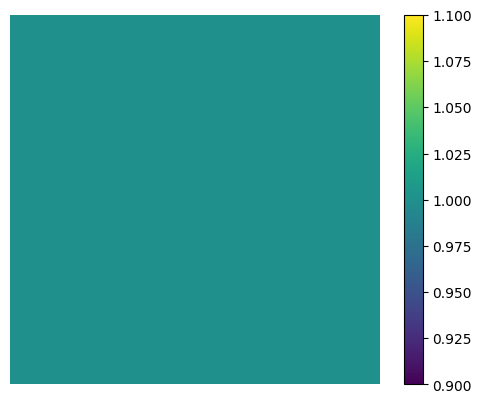

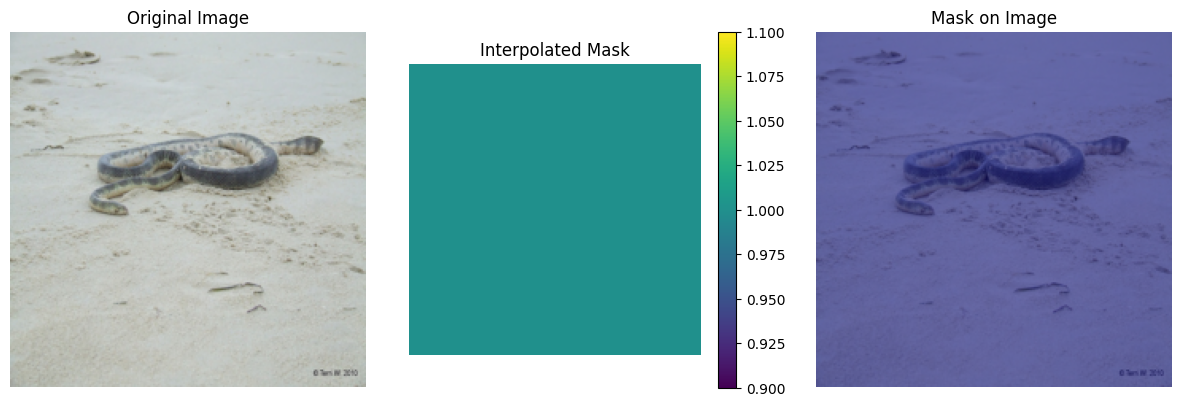

In [22]:
# Step 5: Visualize the mask
import matplotlib.pyplot as plt
def visualize_mask(mask):
    mask_np = mask.squeeze().cpu().numpy()
    plt.imshow(mask_np, cmap='viridis')
    plt.axis('off')
    plt.colorbar()
    plt.show()

def visualize_all(img_tensor, mask_tensor, blended_tensor):
    fig, axs = plt.subplots(1, 3, figsize=(12, 4))

    # Original image
    img_np = img_tensor.squeeze().permute(1, 2, 0).cpu().numpy()
    axs[0].imshow(img_np)
    axs[0].set_title("Original Image")
    axs[0].axis('off')

    # Mask
    mask_np = mask_tensor.squeeze().cpu().numpy()
    im1 = axs[1].imshow(mask_np, cmap='viridis')
    axs[1].set_title("Interpolated Mask")
    axs[1].axis('off')
    fig.colorbar(im1, ax=axs[1])

    # Mask on image
    axs[2].imshow(img_np)
    axs[2].imshow(mask_np, cmap='jet', alpha=0.5)
    axs[2].set_title("Mask on Image")
    axs[2].axis('off')

    plt.tight_layout()
    plt.show()

visualize_mask(interpolated_mask[0, 0])
visualize_all(input_tensor, interpolated_mask[0, 0], masked_input)

In [23]:
import torch
import torch.nn as nn
from transformers import ViTPreTrainedModel, ViTModel, ViTConfig
from typing import Tuple
from transformers.modeling_outputs import BaseModelOutputWithPooling

class ViTForMaskGeneration(ViTPreTrainedModel):
    vit: ViTModel
    patch_classifier: nn.Linear

    def __init__(self, config):
        super().__init__(config)

        # Vision Transformer backbone without pooling layer
        self.vit = ViTModel(config, add_pooling_layer=False)

        # Patch-level processing layers
        self.patch_pooler = nn.Linear(config.hidden_size, config.hidden_size)
        self.activation = nn.Tanh()
        self.patch_classifier = nn.Linear(config.hidden_size, 1)  # Regression to a single value per patch

        # Initialize weights and apply final processing
        self.post_init()
        
        # Default settings for image/patch size
        self.img_size = 224
        self.patch_size = 16
        self.use_inpaint_model = False

    def extract_patch_logits(self, tokens_output):
        logits = self.patch_classifier(
            self.activation(self.patch_pooler(tokens_output.reshape(-1, tokens_output.shape[-1]))))
        return logits, tokens_output.shape[0], tokens_output.shape[1]

    def generate_mask(self, logits, batch_size):
        # Convert logits to probabilities with sigmoid, threshold, and sample in one step
        relevance_threshold = 0.3
        sampled_mask_probs = torch.bernoulli(torch.clamp(torch.sigmoid(logits), min=relevance_threshold))

        patch_dim = int(self.img_size / self.patch_size)
        sampled_mask = sampled_mask_probs.view(batch_size, 1, patch_dim, patch_dim)

        interpolated_mask = torch.nn.functional.interpolate(
            sampled_mask, scale_factor=self.patch_size, mode='bilinear'
        )
        return sampled_mask, interpolated_mask

    def binarize_mask(self, interpolated_mask):
        # Binarize the mask after interpolation
        binary_mask = (interpolated_mask > 0.5).float()
        return binary_mask

    def generate_mask_without_inpainting(self, logits, batch_size, tokens_count):
        mask = logits.view(batch_size, tokens_count, 1)
        
        # Default to sigmoid activation
        mask = torch.sigmoid(mask)

        patch_dim = int(self.img_size / self.patch_size)
        sampled_mask = mask.view(batch_size, patch_dim, patch_dim, 1).permute(0, 3, 1, 2)
        interpolated_mask = torch.nn.functional.interpolate(
            sampled_mask, scale_factor=self.patch_size, mode='bilinear'
        )
        inpainted_image = None
        return sampled_mask, interpolated_mask, inpainted_image

    def forward(
            self,
            pixel_values=None,
            head_mask=None,
            output_attentions=None,
            output_hidden_states=None,
            interpolate_pos_encoding=None,
            top2_classes=None,
    ) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
        # --- Feature Extraction ---
        outputs: BaseModelOutputWithPooling = self.vit(
            pixel_values,
            head_mask=head_mask,
            output_attentions=output_attentions,
            output_hidden_states=output_hidden_states,
            interpolate_pos_encoding=interpolate_pos_encoding,
            return_dict=True,
        )
        sequence_output = outputs.last_hidden_state  # [batch_size, tokens, hidden_size]
        tokens_output = sequence_output[:, 1:, :]  # Remove CLS token

        logits, batch_size, tokens_count = self.extract_patch_logits(tokens_output)
        
        # We're not using inpainting in this example
        sampled_mask, interpolated_mask, inpainted_image = self.generate_mask_without_inpainting(
            logits, batch_size, tokens_count
        )

        # Return tuple: (upsampled mask, patch-level mask, inpainted images if any)
        return interpolated_mask, sampled_mask, inpainted_image


Interpolated mask shape: torch.Size([1, 1, 224, 224])
Sampled mask shape: torch.Size([1, 1, 14, 14])


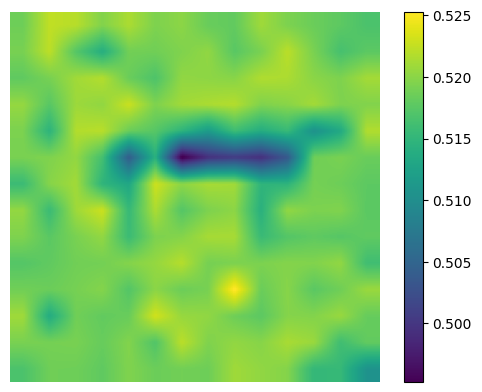

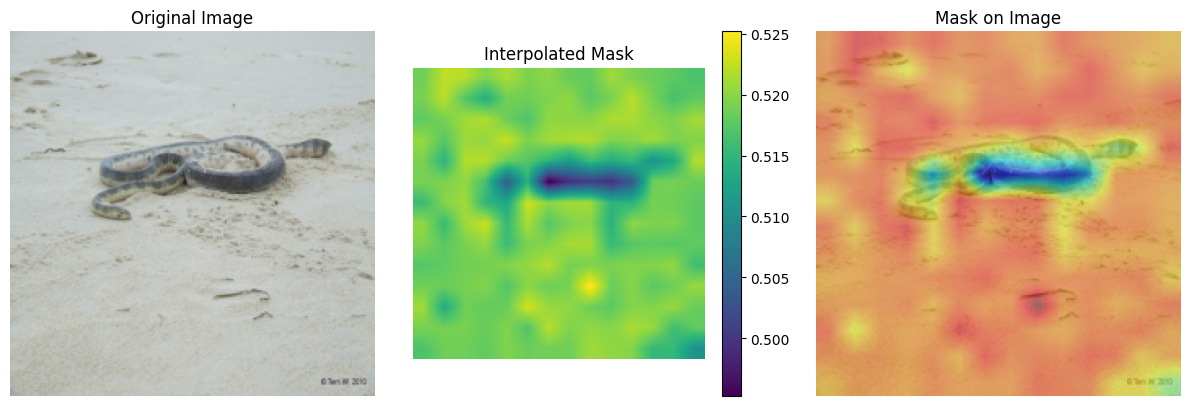

In [24]:
# Initialize and use our ViTForMaskGeneration model
from transformers import ViTConfig

# Create ViT config with appropriate parameters
vit_config = ViTConfig(
    image_size=224,
    patch_size=16,
    num_channels=3,
    hidden_size=768,
    num_hidden_layers=12,
    num_attention_heads=12,
    intermediate_size=3072,
    hidden_act="gelu",
    hidden_dropout_prob=0.1,
    attention_probs_dropout_prob=0.1,
)

# Initialize model and set to evaluation mode
mask_generator = ViTForMaskGeneration(vit_config)
mask_generator.eval()

# Generate mask using our model
with torch.no_grad():
    interpolated_mask, sampled_mask, _ = mask_generator(pixel_values=input_tensor)

print(f"Interpolated mask shape: {interpolated_mask.shape}")
print(f"Sampled mask shape: {sampled_mask.shape}")

# Apply mask to input image
masked_input = input_tensor * interpolated_mask

# Visualize the generated mask and masked image
visualize_mask(interpolated_mask[0, 0])
visualize_all(input_tensor, interpolated_mask[0, 0], masked_input)


Top predicted class: 65, probability: 0.9684
Second predicted class: 54, probability: 0.0106
Top class probability with mask: 0.9017


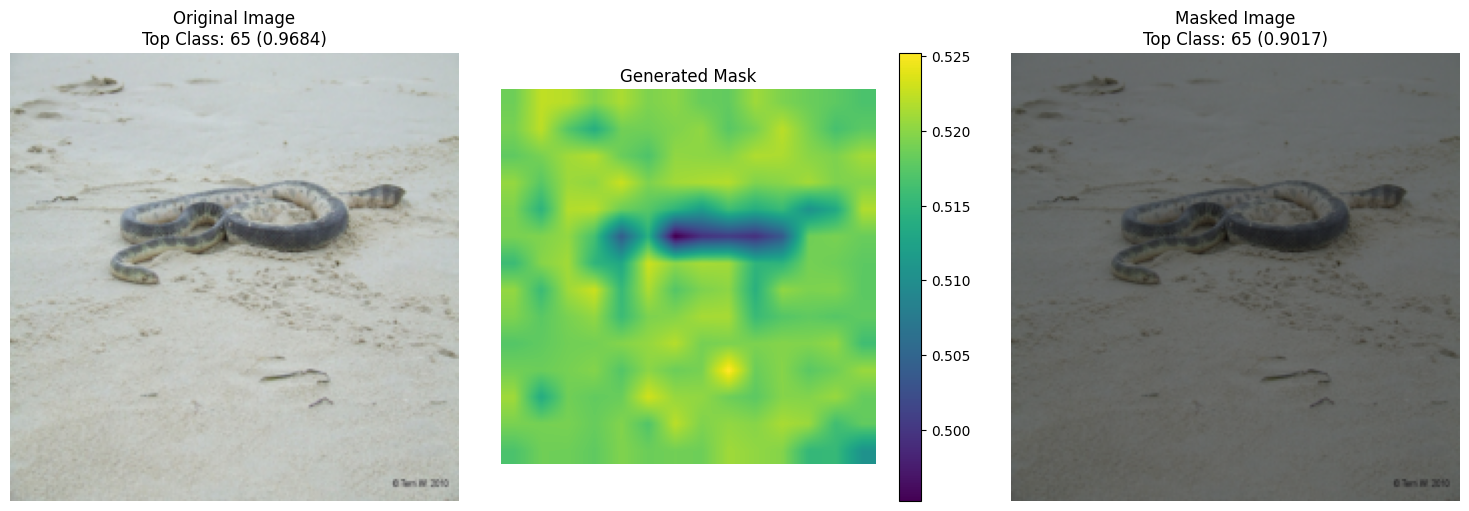

In [25]:
# Compare classification results with and without the generated mask
from transformers import ViTForImageClassification

# Load pre-trained ViT classifier
classifier = ViTForImageClassification.from_pretrained("google/vit-base-patch16-224")
classifier.eval()

with torch.no_grad():
    # Get original classification
    orig_outputs = classifier(input_tensor)
    orig_probs = F.softmax(orig_outputs.logits, dim=-1)
    top2_classes = torch.topk(orig_probs, k=2, dim=-1)
    
    # Get classification with mask applied
    masked_outputs = classifier(masked_input)
    masked_probs = F.softmax(masked_outputs.logits, dim=-1)

# Get top classes and their probabilities
top_class_idx = top2_classes.indices[0][0].item()
second_class_idx = top2_classes.indices[0][1].item()

top_class_prob = orig_probs[0, top_class_idx].item()
second_class_prob = orig_probs[0, second_class_idx].item()
masked_top_class_prob = masked_probs[0, top_class_idx].item()

print(f"Top predicted class: {top_class_idx}, probability: {top_class_prob:.4f}")
print(f"Second predicted class: {second_class_idx}, probability: {second_class_prob:.4f}")
print(f"Top class probability with mask: {masked_top_class_prob:.4f}")

# Create visualization with additional information
fig, axs = plt.subplots(1, 3, figsize=(15, 5))

# Original image
img_np = input_tensor.squeeze().permute(1, 2, 0).cpu().numpy()
axs[0].imshow(img_np)
axs[0].set_title(f"Original Image\nTop Class: {top_class_idx} ({top_class_prob:.4f})")
axs[0].axis('off')

# Generated mask
mask_np = interpolated_mask.squeeze().cpu().numpy()
im1 = axs[1].imshow(mask_np, cmap='viridis')
axs[1].set_title("Generated Mask")
axs[1].axis('off')
fig.colorbar(im1, ax=axs[1])

# Masked image
masked_np = masked_input.squeeze().permute(1, 2, 0).cpu().numpy()
axs[2].imshow(masked_np)
axs[2].set_title(f"Masked Image\nTop Class: {top_class_idx} ({masked_top_class_prob:.4f})")
axs[2].axis('off')

plt.tight_layout()
plt.show()


In [26]:
from dataclasses import dataclass
from torch import Tensor
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision import datasets

# Define LossLossOutput dataclass
@dataclass
class LossLossOutput:
    loss: Tensor
    prediction_loss_multiplied: Tensor
    mask_loss_multiplied: Tensor
    pred_loss: Tensor
    mask_loss: Tensor

# Helper functions for loss calculation
def l1_loss(tokens_mask) -> Tensor:
    return torch.abs(tokens_mask).mean()

def prediction_loss(output,
                    target,
                    target_class,
                    train_model_by_target_gt_class: bool,
                    use_logits_only: bool):
    if train_model_by_target_gt_class:
        target_class_to_compare = target_class
    else:
        target_class_to_compare = torch.argmax(target, dim=1)
    if use_logits_only:
        return -torch.gather(output, 1, target_class_to_compare.unsqueeze(1)).squeeze(1).mean()
    return torch.nn.functional.cross_entropy(output, target_class_to_compare)  # maximize the pred to original model

def encourage_token_mask_to_prior_loss(tokens_mask: Tensor, prior: int = 0):
    if prior == 0:
        target_encourage_patches = torch.zeros_like(tokens_mask)
    elif prior == 1:
        target_encourage_patches = torch.ones_like(tokens_mask)
    else:
        raise NotImplementedError
    bce_encourage_prior_patches_loss = torch.nn.functional.binary_cross_entropy_with_logits(
        tokens_mask, target_encourage_patches
    )
    return bce_encourage_prior_patches_loss

def get_loss_multipliers(normalize: bool, mask_loss_mul: int, prediction_loss_mul: int):
    if normalize:
        total = mask_loss_mul + prediction_loss_mul
        mask_loss_mul = mask_loss_mul / total
        prediction_loss_mul = prediction_loss_mul / total
    return {"mask_loss_mul": mask_loss_mul, "prediction_loss_mul": prediction_loss_mul}


In [27]:
# LossLoss implementation following lossloss.py
@dataclass
class LossLoss:
    mask_loss: str
    prediction_loss_mul: int
    mask_loss_mul: int

    def __post_init__(self):
        loss_multipliers = get_loss_multipliers(normalize=False,
                                                mask_loss_mul=self.mask_loss_mul,
                                                prediction_loss_mul=self.prediction_loss_mul)
        self.prediction_loss_mul = loss_multipliers["prediction_loss_mul"]
        self.mask_loss_mul = loss_multipliers["mask_loss_mul"]
        print(f"Loss multipliers: mask_loss_mul={self.mask_loss_mul}; prediction_loss_mul={self.prediction_loss_mul}")

    def __call__(self, output: Tensor,
                 target: Tensor,
                 tokens_mask: Tensor,
                 target_class: Tensor,
                 activation_function: str,
                 train_model_by_target_gt_class: bool,
                 use_logits_only: bool,
                 is_ce_neg: bool,
                 neg_output: Tensor = None,
                 use_kl_div: bool = False,
                 confidence_drop_loss: bool = False) -> LossLossOutput:
        if self.mask_loss == "bce":
            mask_loss = encourage_token_mask_to_prior_loss(tokens_mask=tokens_mask, prior=0)
        elif self.mask_loss == "l1":
            mask_loss = l1_loss(tokens_mask)
        elif self.mask_loss == "entropy_softmax":
            assert activation_function == 'softmax', \
                "The activation_function must be softmax!!"
            mask_loss = self.entropy_loss(tokens_mask)
        else:
            raise ValueError(f"Value of self.mask_loss '{self.mask_loss}' is not recognized")

        if confidence_drop_loss:
            probs_inpainted = torch.nn.functional.softmax(output, dim=-1)
            probs_original = torch.nn.functional.softmax(neg_output, dim=-1)
            original_conf = probs_original[torch.arange(probs_original.size(0)), target_class]
            inpainted_conf = probs_inpainted[torch.arange(probs_inpainted.size(0)), target_class]
            confidence_drop = original_conf - inpainted_conf
            pred_loss = -confidence_drop.mean()  # encourage bigger drop
        elif use_kl_div:
            log_probs_inpainted = torch.nn.functional.log_softmax(output, dim=-1)
            probs_original = torch.nn.functional.softmax(target, dim=-1)
            kl_div_per_token = torch.nn.functional.kl_div(log_probs_inpainted, probs_original, reduction='none')  # shape: [B, C]
            kl_div_per_example = kl_div_per_token.sum(dim=-1)  # shape: [B]
            importance_mask = tokens_mask.detach().float().reshape_as(kl_div_per_example)  # shape: [B]
            pred_pos_loss = (kl_div_per_example * importance_mask).sum() / (importance_mask.sum() + 1e-8)
            pred_loss = pred_pos_loss
        else:
            pred_pos_loss = prediction_loss(output=output,
                                            target=target,
                                            target_class=target_class,
                                            train_model_by_target_gt_class=train_model_by_target_gt_class,
                                            use_logits_only=use_logits_only)
            pred_loss = pred_pos_loss
            if is_ce_neg:
                pred_neg_loss = -1 * prediction_loss(output=neg_output,
                                                     target=target,
                                                     target_class=target_class,
                                                     train_model_by_target_gt_class=train_model_by_target_gt_class,
                                                     use_logits_only=use_logits_only)
                pred_loss = (pred_pos_loss + pred_neg_loss) / 2

        prediction_loss_multiplied = self.prediction_loss_mul * pred_loss
        mask_loss_multiplied = self.mask_loss_mul * mask_loss
        loss = prediction_loss_multiplied + mask_loss_multiplied
        return LossLossOutput(
            loss=loss,
            prediction_loss_multiplied=prediction_loss_multiplied,
            mask_loss_multiplied=mask_loss_multiplied,
            pred_loss=pred_loss,
            mask_loss=mask_loss,
        )

    def entropy_loss(self, tokens_mask: Tensor):
        tokens_mask_reshape = tokens_mask.reshape(tokens_mask.shape[0], -1)
        d = torch.distributions.Categorical(tokens_mask_reshape + 1e-8)
        normalized_entropy = d.entropy() / np.log(d.param_shape[-1])
        mask_loss = normalized_entropy.mean()
        return mask_loss


In [28]:
# Create a simple ImageNet dataset wrapper for training
class ImageNetSubset(Dataset):
    def __init__(self, root, transform=None, num_samples=1000):
        self.dataset = datasets.ImageFolder(root=root, transform=transform)
        self.num_samples = min(num_samples, len(self.dataset))
        self.indices = list(range(self.num_samples))
        
    def __len__(self):
        return self.num_samples
    
    def __getitem__(self, idx):
        return self.dataset[self.indices[idx]]


# Define the training function for ViTForMaskGeneration
def train_mask_generator(
    mask_generator,
    classifier,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    num_epochs=10,
    device='cuda' if torch.cuda.is_available() else 'cpu',
    activation_function='sigmoid',
    train_model_by_target_gt_class=True,
    use_logits_only=False,
    is_ce_neg=False,
    use_kl_div=False,
    save_path='mask_generator.pt'
):
    mask_generator = mask_generator.to(device)
    classifier = classifier.to(device)
    classifier.eval()  # We use the classifier for evaluation only, no training
    
    best_val_loss = float('inf')
    
    for epoch in range(num_epochs):
        # Training phase
        mask_generator.train()
        total_train_loss = 0
        total_pred_loss = 0
        total_mask_loss = 0
        
        for batch_idx, (images, labels) in enumerate(train_loader):
            images, labels = images.to(device), labels.to(device)
            batch_size = images.size(0)
            
            # Zero the parameter gradients
            optimizer.zero_grad()
            
            # Forward pass through classifier to get target logits
            with torch.no_grad():
                target_logits = classifier(images).logits
            
            # Generate masks
            interpolated_mask, sampled_mask, _ = mask_generator(pixel_values=images)
            
            # Apply mask to images
            masked_images = images * interpolated_mask
            
            # Forward pass through classifier with masked images
            masked_logits = classifier(masked_images).logits
            
            # Calculate loss
            loss_output = criterion(
                output=masked_logits,
                target=target_logits,
                tokens_mask=sampled_mask.view(batch_size, -1),  # Reshape mask to match expected format
                target_class=labels,
                activation_function=activation_function,
                train_model_by_target_gt_class=train_model_by_target_gt_class,
                use_logits_only=use_logits_only,
                is_ce_neg=is_ce_neg,
                neg_output=target_logits if is_ce_neg else None,
                use_kl_div=use_kl_div
            )
            
            loss = loss_output.loss
            loss.backward()
            optimizer.step()
            
            # Track statistics
            total_train_loss += loss.item()
            total_pred_loss += loss_output.pred_loss.item()
            total_mask_loss += loss_output.mask_loss.item()
            
            if batch_idx % 10 == 0:
                print(f'Epoch {epoch+1}/{num_epochs}, Batch {batch_idx}/{len(train_loader)}, '
                      f'Loss: {loss.item():.4f}, Pred Loss: {loss_output.pred_loss.item():.4f}, '
                      f'Mask Loss: {loss_output.mask_loss.item():.4f}')
        
        avg_train_loss = total_train_loss / len(train_loader)
        avg_pred_loss = total_pred_loss / len(train_loader)
        avg_mask_loss = total_mask_loss / len(train_loader)
        
        print(f'Epoch {epoch+1}/{num_epochs}, Average Train Loss: {avg_train_loss:.4f}, '
              f'Average Pred Loss: {avg_pred_loss:.4f}, Average Mask Loss: {avg_mask_loss:.4f}')
        
        # Validation phase
        mask_generator.eval()
        total_val_loss = 0
        
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                batch_size = images.size(0)
                
                # Forward pass through classifier to get target logits
                target_logits = classifier(images).logits
                
                # Generate masks
                interpolated_mask, sampled_mask, _ = mask_generator(pixel_values=images)
                
                # Apply mask to images
                masked_images = images * interpolated_mask
                
                # Forward pass through classifier with masked images
                masked_logits = classifier(masked_images).logits
                
                # Calculate loss
                loss_output = criterion(
                    output=masked_logits,
                    target=target_logits,
                    tokens_mask=sampled_mask.view(batch_size, -1),
                    target_class=labels,
                    activation_function=activation_function,
                    train_model_by_target_gt_class=train_model_by_target_gt_class,
                    use_logits_only=use_logits_only,
                    is_ce_neg=is_ce_neg,
                    neg_output=target_logits if is_ce_neg else None,
                    use_kl_div=use_kl_div
                )
                
                total_val_loss += loss_output.loss.item()
        
        avg_val_loss = total_val_loss / len(val_loader)
        print(f'Epoch {epoch+1}/{num_epochs}, Validation Loss: {avg_val_loss:.4f}')
        
        # Save best model
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            torch.save(mask_generator.state_dict(), save_path)
            print(f'Saved model to {save_path}')
    
    print(f'Training completed. Best validation loss: {best_val_loss:.4f}')


In [29]:
# Example usage for training the ViTForMaskGeneration model

# Define training parameters
batch_size = 16
num_epochs = 5
learning_rate = 1e-4
weight_decay = 1e-5

# Set up data transforms for training
train_transform = T.Compose([
    T.Resize((224, 224)),
    T.RandomHorizontalFlip(),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transform = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Note: Replace 'path/to/imagenet/train' and 'path/to/imagenet/val' with actual paths
# For demonstration purposes, we're creating dummy datasets
"""
# Actual ImageNet dataset loading would be:
train_dataset = ImageNetSubset(root='path/to/imagenet/train', transform=train_transform, num_samples=1000)
val_dataset = ImageNetSubset(root='path/to/imagenet/val', transform=val_transform, num_samples=200)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=4)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=4)
"""

# For demo, we'll just use a small dummy dataset
device = 'cuda' if torch.cuda.is_available() else 'cpu'

# Initialize models
mask_generator = ViTForMaskGeneration(vit_config)
classifier = ViTForImageClassification.from_pretrained("google/vit-base-patch16-224")

# Create LossLoss criterion
criterion = LossLoss(
    mask_loss="l1",  # Options: "l1", "bce", "entropy_softmax"
    prediction_loss_mul=10,  # Higher weight for prediction loss
    mask_loss_mul=1,  # Lower weight for mask loss
)

# Create optimizer
optimizer = optim.AdamW(
    mask_generator.parameters(),
    lr=learning_rate,
    weight_decay=weight_decay
)

# Example for running training (commented out since we don't have the actual datasets)
"""
train_mask_generator(
    mask_generator=mask_generator,
    classifier=classifier,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    num_epochs=num_epochs,
    device=device,
    activation_function='sigmoid',
    train_model_by_target_gt_class=True,
    use_logits_only=False,
    is_ce_neg=True,  # Use negative CE loss
    save_path='mask_generator_model.pt'
)
"""


Loss multipliers: mask_loss_mul=1; prediction_loss_mul=10


"\ntrain_mask_generator(\n    mask_generator=mask_generator,\n    classifier=classifier,\n    train_loader=train_loader,\n    val_loader=val_loader,\n    criterion=criterion,\n    optimizer=optimizer,\n    num_epochs=num_epochs,\n    device=device,\n    activation_function='sigmoid',\n    train_model_by_target_gt_class=True,\n    use_logits_only=False,\n    is_ce_neg=True,  # Use negative CE loss\n    save_path='mask_generator_model.pt'\n)\n"

In [30]:
# For demonstration purposes, let's create a small synthetic dataset and run a minimized training loop

# Create a small synthetic dataset of random images and labels
def create_synthetic_dataset(num_samples=100, img_size=224, num_classes=1000):
    images = torch.rand(num_samples, 3, img_size, img_size)
    labels = torch.randint(0, num_classes, (num_samples,))
    return torch.utils.data.TensorDataset(images, labels)

# Create synthetic datasets
train_dataset = create_synthetic_dataset(num_samples=100)
val_dataset = create_synthetic_dataset(num_samples=20)

# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=4, shuffle=False)

# Set device to CPU for demonstration
device = 'cpu'

# Initialize models (reduced configuration for faster execution)
mini_vit_config = ViTConfig(
    image_size=224,
    patch_size=16,
    num_channels=3,
    hidden_size=192,  # Reduced
    num_hidden_layers=4,  # Reduced
    num_attention_heads=3,  # Reduced
    intermediate_size=768,  # Reduced
    hidden_act="gelu",
    hidden_dropout_prob=0.1,
    attention_probs_dropout_prob=0.1,
)

mask_generator = ViTForMaskGeneration(mini_vit_config)
classifier = ViTForImageClassification.from_pretrained("google/vit-base-patch16-224")

# Create LossLoss criterion
criterion = LossLoss(
    mask_loss="l1",  
    prediction_loss_mul=10,
    mask_loss_mul=1,
)

# Create optimizer
optimizer = optim.AdamW(
    mask_generator.parameters(),
    lr=1e-4,
    weight_decay=1e-5
)

# Minimal training for demonstration - 1 epoch, 5 steps
def mini_train():
    mask_generator.train()
    
    print("Starting mini-training demonstration...")
    
    # Run for just a few steps
    for batch_idx, (images, labels) in enumerate(train_loader):
        if batch_idx >= 5:  # Only run 5 steps
            break
            
        images, labels = images.to(device), labels.to(device)
        batch_size = images.size(0)
        
        # Zero gradients
        optimizer.zero_grad()
        
        # Forward pass through classifier to get target logits
        with torch.no_grad():
            target_logits = classifier(images).logits
        
        # Generate masks
        interpolated_mask, sampled_mask, _ = mask_generator(pixel_values=images)
        
        # Apply mask to images
        masked_images = images * interpolated_mask
        
        # Forward pass through classifier with masked images
        masked_logits = classifier(masked_images).logits
        
        # Calculate loss
        loss_output = criterion(
            output=masked_logits,
            target=target_logits,
            tokens_mask=sampled_mask.view(batch_size, -1),
            target_class=labels,
            activation_function='sigmoid',
            train_model_by_target_gt_class=True,
            use_logits_only=False,
            is_ce_neg=False,
            neg_output=None,
            use_kl_div=False
        )
        
        # Backward pass and optimize
        loss = loss_output.loss
        loss.backward()
        optimizer.step()
        
        print(f"Step {batch_idx+1}/5, Loss: {loss.item():.4f}, "
              f"Pred Loss: {loss_output.pred_loss.item():.4f}, "
              f"Mask Loss: {loss_output.mask_loss.item():.4f}")
    
    print("Mini-training completed")

    # Visualize results with one example
    mask_generator.eval()
    with torch.no_grad():
        example_img = next(iter(val_loader))[0][0:1]
        interp_mask, _, _ = mask_generator(pixel_values=example_img)
        
        # Visualize the generated mask
        visualize_mask(interp_mask[0, 0])
        visualize_all(example_img, interp_mask[0, 0], example_img * interp_mask)


Loss multipliers: mask_loss_mul=1; prediction_loss_mul=10


In [41]:
# Let's use the actual ImageNet dataset available on the server
import os
import pytorch_lightning as pl
from torch.utils.data import DataLoader
from transformers import ViTFeatureExtractor

# Define the path to the ImageNet validation dataset
IMAGENET_VAL_IMAGES_FOLDER_PATH = "/home/amitesh/Projects/explainablity-transformer-cv/vit_data"

# Implementing the required dataset classes based on image_token_data_module.py
class ImageSegDataset:
    def __init__(
            self,
            images_path: str,
            feature_extractor=None,
            is_sampled_train_data_uniformly=True,
            is_sampled_val_data_uniformly=True,
            train_n_label_sample=1000,
            val_n_label_sample=500,
    ):
        self.images_path = images_path
        # Get all image files from the directory
        all_files = [f for f in os.listdir(images_path) if f.endswith(('.JPEG', '.jpg', '.png'))]
        
        # For simplicity, we'll use 80% for training and 20% for validation
        split_idx = int(0.8 * len(all_files))
        self.train_set = all_files[:1]
        self.val_set = all_files[1:2]
        
        # Since we don't have ground truth files, we'll use dummy targets (0 for all)
        self.train_gt_classes = [0] * len(self.train_set)
        self.val_gt_classes = [0] * len(self.val_set)
        
        print(f"Created dataset with {len(self.train_set)} training images and {len(self.val_set)} validation images")

class ImagesDataset(torch.utils.data.Dataset):
    def __init__(
            self,
            images_path: str,
            images_name: list,
            targets: list,
            is_explaniee_convnet=False,
            is_competitive_method_transforms=False,
            feature_extractor=None,
    ):
        self.images_path = images_path
        self.images_name = images_name
        self.targets = targets
        
        # Initialize the feature extractor if not provided
        if feature_extractor is None:
            self.feature_extractor = ViTFeatureExtractor.from_pretrained("google/vit-base-patch16-224")
        else:
            self.feature_extractor = feature_extractor
        
        # Set up transforms
        self.transform = T.Compose([
            T.Resize((224, 224)),
            T.ToTensor(),
            T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])

    def __len__(self):
        return len(self.images_name)

    def __getitem__(self, idx):
        img_name = self.images_name[idx]
        img_path = os.path.join(self.images_path, img_name)
        
        # Load image
        img = Image.open(img_path).convert('RGB')
        img_tensor = self.transform(img)
        
        # Get target class
        target = torch.tensor(self.targets[idx], dtype=torch.long)
        
        return img_tensor, target

class ImageSegDataModule(pl.LightningDataModule):
    def __init__(
            self,
            batch_size: int,
            train_images_path: str,
            val_images_path: str,
            is_sampled_train_data_uniformly: bool = True,
            is_sampled_val_data_uniformly: bool = True,
            is_explaniee_convnet: bool = False,
            is_competitive_method_transforms: bool = False,
            train_n_label_sample: int = 1,
            val_n_label_sample: int = 1,
            feature_extractor = None,
    ):
        super().__init__()
        self.batch_size = batch_size
        self.train_images_path = train_images_path
        self.val_images_path = val_images_path
        self.is_sampled_train_data_uniformly = is_sampled_train_data_uniformly
        self.is_sampled_val_data_uniformly = is_sampled_val_data_uniformly
        self.is_explaniee_convnet = is_explaniee_convnet
        self.is_competitive_method_transforms = is_competitive_method_transforms
        self.train_n_label_sample = train_n_label_sample
        self.val_n_label_sample = val_n_label_sample
        self.feature_extractor = feature_extractor

    def setup(self, stage=None):
        dataset = ImageSegDataset(
            images_path=self.train_images_path,
            feature_extractor=self.feature_extractor,
            is_sampled_train_data_uniformly=self.is_sampled_train_data_uniformly,
            is_sampled_val_data_uniformly=self.is_sampled_val_data_uniformly,
            train_n_label_sample=self.train_n_label_sample,
            val_n_label_sample=self.val_n_label_sample,
        )
        
        self.train_dataset = ImagesDataset(
            images_path=self.train_images_path,
            images_name=dataset.train_set,
            targets=dataset.train_gt_classes,
            is_explaniee_convnet=self.is_explaniee_convnet,
            is_competitive_method_transforms=self.is_competitive_method_transforms,
            feature_extractor=self.feature_extractor,
        )

        self.val_dataset = ImagesDataset(
            images_path=self.val_images_path,
            images_name=dataset.val_set,
            targets=dataset.val_gt_classes,
            is_explaniee_convnet=self.is_explaniee_convnet,
            is_competitive_method_transforms=self.is_competitive_method_transforms,
            feature_extractor=self.feature_extractor,
        )

    def train_dataloader(self):
        return DataLoader(dataset=self.train_dataset, batch_size=self.batch_size, shuffle=True)

    def val_dataloader(self):
        return DataLoader(dataset=self.val_dataset, batch_size=self.batch_size, shuffle=False)


In [42]:
# Setup DataModule and training with the actual ImageNet dataset
import pytorch_lightning as pl
from pytorch_lightning.callbacks import ModelCheckpoint

# Create a PyTorch Lightning module for training the mask generator
class MaskGeneratorModule(pl.LightningModule):
    def __init__(
        self,
        mask_generator,
        classifier,
        criterion,
        learning_rate=1e-4,
        weight_decay=1e-5,
        activation_function='sigmoid',
        train_model_by_target_gt_class=True,
        use_logits_only=False,
        is_ce_neg=False,
        use_kl_div=False
    ):
        super().__init__()
        self.mask_generator = mask_generator
        self.classifier = classifier
        self.criterion = criterion
        self.learning_rate = learning_rate
        self.weight_decay = weight_decay
        self.activation_function = activation_function
        self.train_model_by_target_gt_class = train_model_by_target_gt_class
        self.use_logits_only = use_logits_only
        self.is_ce_neg = is_ce_neg
        self.use_kl_div = use_kl_div
        
        # Freeze the classifier
        for param in self.classifier.parameters():
            param.requires_grad = False
        
    def forward(self, x):
        return self.mask_generator(pixel_values=x)
    
    def training_step(self, batch, batch_idx):
        images, labels = batch
        batch_size = images.size(0)
        
        # Forward pass through classifier to get target logits
        with torch.no_grad():
            target_logits = self.classifier(images).logits
        
        # Generate masks
        interpolated_mask, sampled_mask, _ = self.mask_generator(pixel_values=images)
        
        # Apply mask to images
        masked_images = images * interpolated_mask
        
        # Forward pass through classifier with masked images
        masked_logits = self.classifier(masked_images).logits
        
        # Calculate loss
        loss_output = self.criterion(
            output=masked_logits,
            target=target_logits,
            tokens_mask=sampled_mask.view(batch_size, -1),
            target_class=labels,
            activation_function=self.activation_function,
            train_model_by_target_gt_class=self.train_model_by_target_gt_class,
            use_logits_only=self.use_logits_only,
            is_ce_neg=self.is_ce_neg,
            neg_output=target_logits if self.is_ce_neg else None,
            use_kl_div=self.use_kl_div
        )
        
        # Log metrics
        self.log('train_loss', loss_output.loss)
        self.log('train_pred_loss', loss_output.pred_loss)
        self.log('train_mask_loss', loss_output.mask_loss)
        
        return loss_output.loss
    
    def validation_step(self, batch, batch_idx):
        images, labels = batch
        batch_size = images.size(0)
        
        # Forward pass through classifier to get target logits
        with torch.no_grad():
            target_logits = self.classifier(images).logits
        
        # Generate masks
        interpolated_mask, sampled_mask, _ = self.mask_generator(pixel_values=images)
        
        # Apply mask to images
        masked_images = images * interpolated_mask
        
        # Forward pass through classifier with masked images
        masked_logits = self.classifier(masked_images).logits
        
        # Calculate loss
        loss_output = self.criterion(
            output=masked_logits,
            target=target_logits,
            tokens_mask=sampled_mask.view(batch_size, -1),
            target_class=labels,
            activation_function=self.activation_function,
            train_model_by_target_gt_class=self.train_model_by_target_gt_class,
            use_logits_only=self.use_logits_only,
            is_ce_neg=self.is_ce_neg,
            neg_output=target_logits if self.is_ce_neg else None,
            use_kl_div=self.use_kl_div
        )
        
        # Log metrics
        self.log('val_loss', loss_output.loss)
        self.log('val_pred_loss', loss_output.pred_loss)
        self.log('val_mask_loss', loss_output.mask_loss)
        
        return loss_output.loss
    
    def configure_optimizers(self):
        optimizer = torch.optim.AdamW(
            self.mask_generator.parameters(),
            lr=self.learning_rate,
            weight_decay=self.weight_decay
        )
        return optimizer


Created dataset with 1 training images and 1 validation images


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name           | Type                      | Params
-------------------------------------------------------------
0 | mask_generator | ViTForMaskGeneration      | 11.2 M
1 | classifier     | ViTForImageClassification | 86.6 M
-------------------------------------------------------------
11.2 M    Trainable params
86.6 M    Non-trainable params
97.7 M    Total params
390.939   Total estimated model params size (MB)


Loss multipliers: mask_loss_mul=1; prediction_loss_mul=10
Created dataset with 1 training images and 1 validation images


Sanity Checking: 0it [00:00, ?it/s]

/home/amitesh/work/conda/envs/nlp_env/lib/python3.7/site-packages/pytorch_lightning/trainer/trainer.py:1613: PossibleUserWarning: The number of training batches (1) is smaller than the logging interval Trainer(log_every_n_steps=10). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.
  category=PossibleUserWarning,


...

Validation: 0it [00:00, ?it/s]

Validation: 0it [00:00, ?it/s]

Validation: 0it [00:00, ?it/s]

`Trainer.fit` stopped: `max_epochs=10` reached.


Best model saved at: /home/amitesh/Projects/explainablity-transformer-cv/checkpoints/mask-generator-epoch=00-val_loss=8.58.ckpt


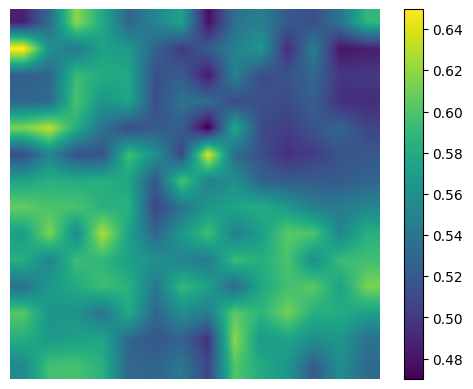

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


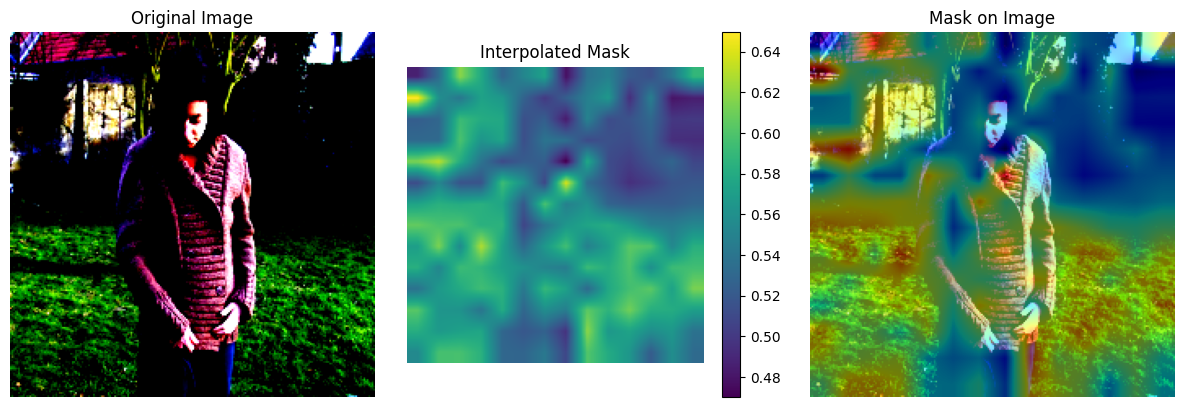

In [43]:
# Set up the training with the actual ImageNet dataset
def setup_and_train_with_real_data():
    # Define training parameters
    batch_size = 1
    max_epochs = 10
    learning_rate = 1e-4
    weight_decay = 1e-5
    
    # Initialize feature extractor
    feature_extractor = ViTFeatureExtractor.from_pretrained("google/vit-base-patch16-224")
    
    # Create data module
    data_module = ImageSegDataModule(
        batch_size=batch_size,
        train_images_path=IMAGENET_VAL_IMAGES_FOLDER_PATH,
        val_images_path=IMAGENET_VAL_IMAGES_FOLDER_PATH,
        feature_extractor=feature_extractor,
    )
    data_module.setup()
    
    # Initialize models with smaller configuration for faster training
    vit_config = ViTConfig(
        image_size=224,
        patch_size=16,
        num_channels=3,
        hidden_size=384,  # Reduced size
        num_hidden_layers=6,  # Reduced layers
        num_attention_heads=6,
        intermediate_size=1536,
        hidden_act="gelu",
        hidden_dropout_prob=0.1,
        attention_probs_dropout_prob=0.1,
    )
    
    mask_generator = ViTForMaskGeneration(vit_config)
    classifier = ViTForImageClassification.from_pretrained("google/vit-base-patch16-224")
    
    # Create LossLoss criterion
    criterion = LossLoss(
        mask_loss="l1",
        prediction_loss_mul=10,
        mask_loss_mul=1,
    )
    
    # Create Lightning module
    model = MaskGeneratorModule(
        mask_generator=mask_generator,
        classifier=classifier,
        criterion=criterion,
        learning_rate=learning_rate,
        weight_decay=weight_decay,
        is_ce_neg=True  # Use negative CE loss
    )
    
    # Setup checkpointing
    checkpoint_callback = ModelCheckpoint(
        dirpath='checkpoints',
        filename='mask-generator-{epoch:02d}-{val_loss:.2f}',
        save_top_k=3,
        monitor='val_loss',
        mode='min'
    )
    
    # Create trainer
    trainer = pl.Trainer(
        max_epochs=max_epochs,
        accelerator='gpu' if torch.cuda.is_available() else 'cpu',
        callbacks=[checkpoint_callback],
        log_every_n_steps=10,
    )
    
    # Train model
    trainer.fit(model, data_module)
    
    # Load best model
    best_model_path = checkpoint_callback.best_model_path
    print(f"Best model saved at: {best_model_path}")
    
    # Load and display the results from best model
    best_model = MaskGeneratorModule.load_from_checkpoint(
        best_model_path,
        mask_generator=mask_generator,
        classifier=classifier,
        criterion=criterion
    )
    
    # Display some example results
    best_model.eval()
    with torch.no_grad():
        val_loader = data_module.val_dataloader()
        batch = next(iter(val_loader))
        images, _ = batch
        
        # Get a single image for demonstration
        sample_image = images[0:1]
        
        # Generate mask
        interpolated_mask, sampled_mask, _ = best_model.mask_generator(pixel_values=sample_image)
        masked_image = sample_image * interpolated_mask
        
        # Display results
        visualize_mask(interpolated_mask[0, 0])
        visualize_all(sample_image, interpolated_mask[0, 0], masked_image)

# Uncomment to run the training
setup_and_train_with_real_data()


Attempting to access images in: /home/amitesh/Projects/explainablity-transformer-cv/vit_data
Found 50000 image files. First few: ['ILSVRC2012_val_00000001.JPEG', 'ILSVRC2012_val_00000002.JPEG', 'ILSVRC2012_val_00000003.JPEG', 'ILSVRC2012_val_00000004.JPEG', 'ILSVRC2012_val_00000005.JPEG']
Found target image: ILSVRC2012_val_00000001.JPEG
Using image: /home/amitesh/Projects/explainablity-transformer-cv/vit_data/ILSVRC2012_val_00000001.JPEG
Loss multipliers: mask_loss_mul=1; prediction_loss_mul=10
Original prediction: Class 65 with confidence 0.9667
Masked prediction: Class 65 with confidence 0.9891
Visualizing the mask and its effects on the image:


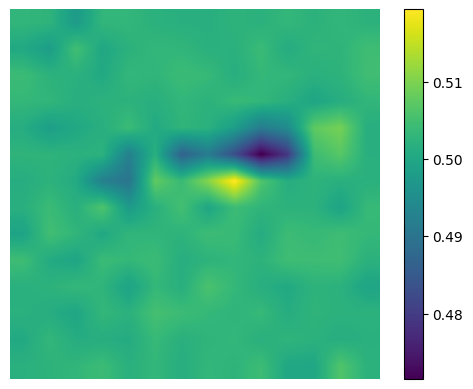

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


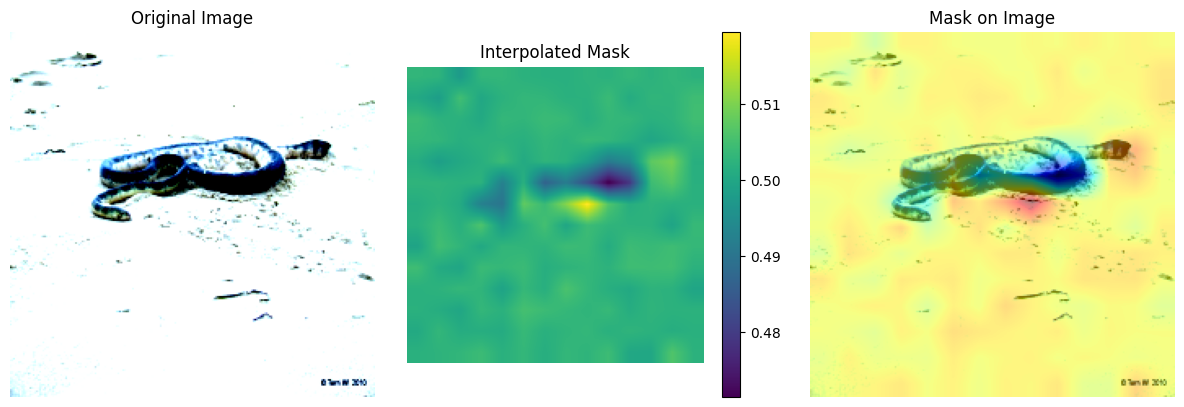

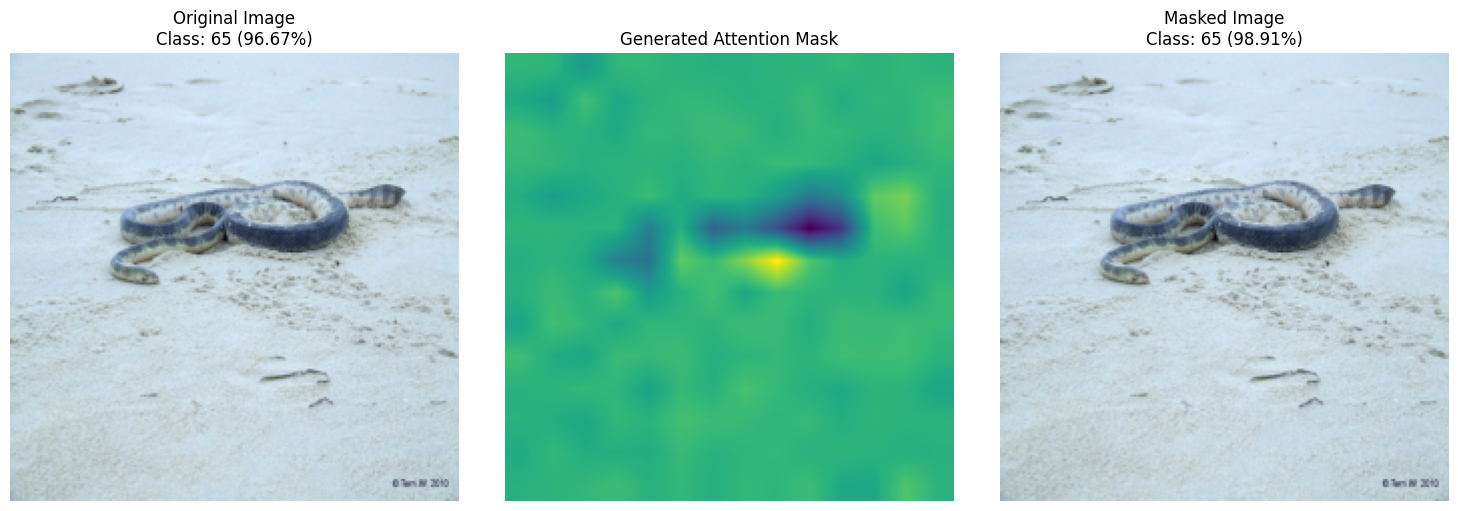

In [44]:
# A minimal demonstration with a single image from the actual dataset
def demonstrate_with_single_image():
    # Load a single image from the ImageNet dataset path
    try:
        print(f"Attempting to access images in: {IMAGENET_VAL_IMAGES_FOLDER_PATH}")
        image_files = [f for f in os.listdir(IMAGENET_VAL_IMAGES_FOLDER_PATH) 
                       if f.endswith(('.JPEG', '.jpg', '.png'))]
        
        # Sort image files so we can get ILSVRC2012_val_00000001
        image_files.sort()
        
        print(f"Found {len(image_files)} image files. First few: {image_files[:5] if len(image_files) >= 5 else image_files}")
        
        if not image_files:
            print("No image files found. Using a random tensor for demonstration.")
            # If no images found, create a random tensor
            img_tensor = torch.rand(1, 3, 224, 224)
        else:
            # Look for ILSVRC2012_val_00000001.JPEG specifically
            target_image = "ILSVRC2012_val_00000001.JPEG"
            if target_image in image_files:
                print(f"Found target image: {target_image}")
                sample_img_path = os.path.join(IMAGENET_VAL_IMAGES_FOLDER_PATH, target_image)
            else:
                # Get the first image from sorted list
                sample_img_path = os.path.join(IMAGENET_VAL_IMAGES_FOLDER_PATH, image_files[0])
            
            print(f"Using image: {sample_img_path}")
            
            # Load and transform the image
            img = Image.open(sample_img_path).convert('RGB')
            transform = T.Compose([
                T.Resize((224, 224)),
                T.ToTensor(),
                T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
            ])
            img_tensor = transform(img).unsqueeze(0)
    
    except Exception as e:
        print(f"Error accessing the dataset: {e}")
        # Create a random tensor for demonstration
        img_tensor = torch.rand(1, 3, 224, 224)
    
    # Create a small version of the mask generator model
    small_vit_config = ViTConfig(
        image_size=224,
        patch_size=16,
        num_channels=3,
        hidden_size=192,
        num_hidden_layers=4,
        num_attention_heads=3,
        intermediate_size=768,
        hidden_act="gelu",
        hidden_dropout_prob=0.1,
        attention_probs_dropout_prob=0.1,
    )
    
    mask_gen = ViTForMaskGeneration(small_vit_config)
    
    # Create a LossLoss criterion
    criterion = LossLoss(
        mask_loss="l1",
        prediction_loss_mul=10,
        mask_loss_mul=1,
    )
    
    # Load the classifier
    classifier = ViTForImageClassification.from_pretrained("google/vit-base-patch16-224")
    
    # Set both models to evaluation mode
    mask_gen.eval()
    classifier.eval()
    
    with torch.no_grad():
        # Run the classifier on the original image
        original_outputs = classifier(img_tensor)
        original_probs = F.softmax(original_outputs.logits, dim=-1)
        top_class_idx = original_probs.argmax(dim=-1).item()
        top_class_prob = original_probs[0, top_class_idx].item()
        
        # Generate mask
        interpolated_mask, sampled_mask, _ = mask_gen(pixel_values=img_tensor)
        
        # Apply mask to image
        masked_img = img_tensor * interpolated_mask
        
        # Run the classifier on the masked image
        masked_outputs = classifier(masked_img)
        masked_probs = F.softmax(masked_outputs.logits, dim=-1)
        masked_top_class_prob = masked_probs[0, top_class_idx].item()
    
    print(f"Original prediction: Class {top_class_idx} with confidence {top_class_prob:.4f}")
    print(f"Masked prediction: Class {top_class_idx} with confidence {masked_top_class_prob:.4f}")
    
    # Visualize the results
    print("Visualizing the mask and its effects on the image:")
    visualize_mask(interpolated_mask[0, 0])
    visualize_all(img_tensor, interpolated_mask[0, 0], masked_img)
    
    # Create a comparison visualization
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    # Original image with prediction
    img_np = img_tensor.squeeze(0).permute(1, 2, 0).cpu().numpy()
    img_np = (img_np - img_np.min()) / (img_np.max() - img_np.min())  # Normalize for display
    axes[0].imshow(img_np)
    axes[0].set_title(f"Original Image\nClass: {top_class_idx} ({top_class_prob:.2%})")
    axes[0].axis('off')
    
    # Mask
    mask_np = interpolated_mask[0, 0].cpu().numpy()
    axes[1].imshow(mask_np, cmap='viridis')
    axes[1].set_title("Generated Attention Mask")
    axes[1].axis('off')
    
    # Masked image with prediction
    masked_np = masked_img.squeeze(0).permute(1, 2, 0).cpu().numpy()
    masked_np = (masked_np - masked_np.min()) / (masked_np.max() - masked_np.min())  # Normalize for display
    axes[2].imshow(masked_np)
    axes[2].set_title(f"Masked Image\nClass: {top_class_idx} ({masked_top_class_prob:.2%})")
    axes[2].axis('off')
    
    plt.tight_layout()
    plt.show()

# Run the demonstration with a single image
demonstrate_with_single_image()
